### To create a linear array, there should be a set of antenna elements instantiated with separate indices and positions

Let us assume that now we would like to create a receiver linear antenna array with uniform spacing.

The array is made from the same antenna elements.

In [1]:
import numpy as np

from antenna.element import Degree, SimpleAmplitudePattern, SimplePhasePattern, RadiationPattern
from antenna.element import RadiationProperties, ZeroAmplitudePattern, ZeroPhasePattern, FrequencyInstance, AntennaElement, RxTMode

angles: list[Degree] = np.linspace(-90, 90, 1001)

base_phase_pattern = SimplePhasePattern(angles)

base_amplitude_pattern = SimpleAmplitudePattern(angles)

base_pattern = RadiationPattern(
    amplitude=base_amplitude_pattern,
    phase=base_phase_pattern,
)

radiation_properties = RadiationProperties(
    hh_pattern=base_pattern,
    vv_pattern=RadiationPattern(
        amplitude=ZeroAmplitudePattern(angles),
        phase=ZeroPhasePattern(angles),
    ),
    hv_pattern=RadiationPattern(
        amplitude=ZeroAmplitudePattern(angles),
        phase=ZeroPhasePattern(angles),
    ),
)

frequency_instance = FrequencyInstance(
    frequency=77e9,
    radiation=radiation_properties,
    gain=10.0,
    phase=0.0,
    axial_ratio=1.0,
)

antenna_element = AntennaElement(
    frequency_instances=[frequency_instance],
    mode=RxTMode.RECEIVE,
)


### Create a uniform array

In [2]:
from antenna.element import Position, AntennaElementInstance

number_of_elements = 8
distance_between_elements_relative_to_wavelength = 0.5

wavelength = 3e8 / frequency_instance.frequency

element_positions = np.arange(number_of_elements) * distance_between_elements_relative_to_wavelength * wavelength

antenna_elements = []

for step in element_positions:
    position = Position(x=step, y=0.0, z=0.0)
    antenna_elements.append(
        AntennaElementInstance(idx=step, position=position, antenna_element=antenna_element) 
        )

### Phased array ULA

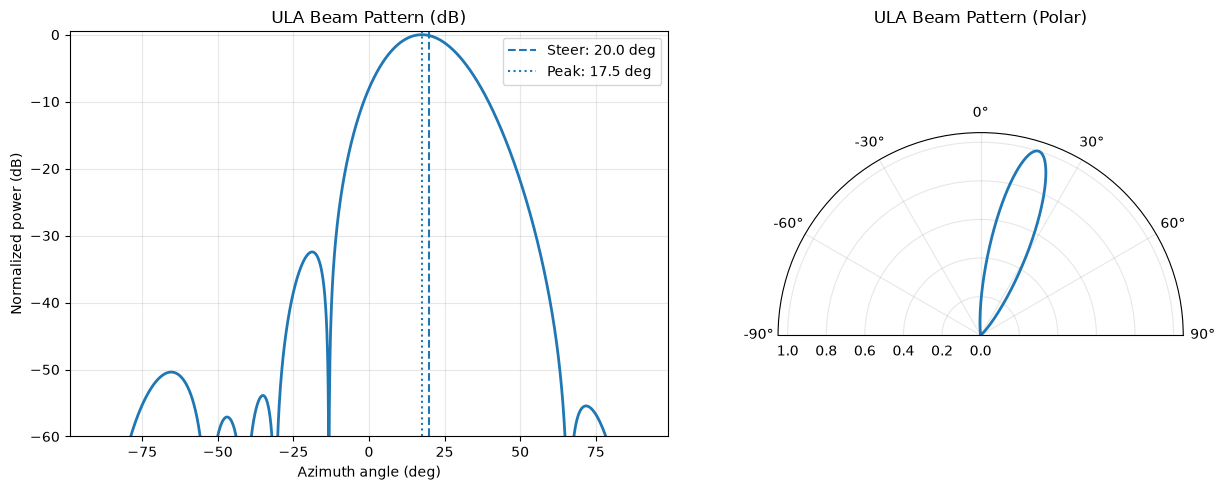

Requested steer angle: 20.00 deg
Measured peak angle:   17.50 deg


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from antenna.ula import ULA

ula = ULA(
    elements=antenna_elements,
    frequency=frequency_instance.frequency,
    axis="x",
)

steer_angle_deg = 20.0
scan_angles_deg = np.linspace(-90.0, 90.0, 1801)

res = ula.beam_scan(
    steer_angle_deg=steer_angle_deg,
    scan_angles_deg=scan_angles_deg,
    taper="hann",
)

fig = plt.figure(figsize=(13, 5))

ax0 = fig.add_subplot(1, 2, 1)
ax0.plot(res.scan_angles_deg, res.power_db, linewidth=2)
ax0.axvline(steer_angle_deg, linestyle="--", linewidth=1.5, label=f"Steer: {steer_angle_deg:.1f} deg")
ax0.axvline(res.peak_angle_deg, linestyle=":", linewidth=1.5, label=f"Peak: {res.peak_angle_deg:.1f} deg")
ax0.set_title("ULA Beam Pattern (dB)")
ax0.set_xlabel("Azimuth angle (deg)")
ax0.set_ylabel("Normalized power (dB)")
ax0.set_ylim(-60, 0.5)
ax0.grid(True, alpha=0.3)
ax0.legend()

ax1 = fig.add_subplot(1, 2, 2, projection="polar")
theta = np.deg2rad(res.scan_angles_deg)
ax1.plot(theta, res.power_linear, linewidth=2)
ax1.set_title("ULA Beam Pattern (Polar)")
ax1.set_theta_zero_location("N")
ax1.set_theta_direction(-1)
ax1.set_thetamin(-90)
ax1.set_thetamax(90)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Requested steer angle: {steer_angle_deg:.2f} deg")
print(f"Measured peak angle:   {res.peak_angle_deg:.2f} deg")